In [40]:
from tensorflow.keras.layers import Dense,Conv2D,Dropout,MaxPooling2D,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam

In [26]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [24]:
import tensorflow.keras.layers as kd
dir(kd)

['AbstractRNNCell',
 'Activation',
 'ActivityRegularization',
 'Add',
 'AdditiveAttention',
 'AlphaDropout',
 'Attention',
 'Average',
 'AveragePooling1D',
 'AveragePooling2D',
 'AveragePooling3D',
 'AvgPool1D',
 'AvgPool2D',
 'AvgPool3D',
 'BatchNormalization',
 'Bidirectional',
 'CategoryEncoding',
 'CenterCrop',
 'Concatenate',
 'Conv1D',
 'Conv1DTranspose',
 'Conv2D',
 'Conv2DTranspose',
 'Conv3D',
 'Conv3DTranspose',
 'ConvLSTM1D',
 'ConvLSTM2D',
 'ConvLSTM3D',
 'Convolution1D',
 'Convolution1DTranspose',
 'Convolution2D',
 'Convolution2DTranspose',
 'Convolution3D',
 'Convolution3DTranspose',
 'Cropping1D',
 'Cropping2D',
 'Cropping3D',
 'Dense',
 'DenseFeatures',
 'DepthwiseConv1D',
 'DepthwiseConv2D',
 'Discretization',
 'Dot',
 'Dropout',
 'ELU',
 'EinsumDense',
 'Embedding',
 'Flatten',
 'GRU',
 'GRUCell',
 'GaussianDropout',
 'GaussianNoise',
 'GlobalAveragePooling1D',
 'GlobalAveragePooling2D',
 'GlobalAveragePooling3D',
 'GlobalAvgPool1D',
 'GlobalAvgPool2D',
 'GlobalAvgPo

In [21]:
def buid_model(hp):
    model=Sequential()
    model.add(Conv2D(unit=hp.Int("units",min_value=2,max_value=332,step=32),activation=hp.Choice("activation",["relu","softmax"],input_shape=(124,124,3),kernel_size=(3,3))))
    model.add(Dropout(np.Float("dropuout",min_value=0.2,max_value=0.6)))

In [53]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [59]:
import tensorflow as tf

x_train = tf.image.resize(x_train[..., None], (128,128))
x_test = tf.image.resize(x_test[..., None], (128,128))

ValueError: 'images' must have either 3 or 4 dimensions.

In [54]:
model=Sequential()
model.add(Conv2D(128,activation="softmax",input_shape=(128,128,1),kernel_size=(3,3),padding="same"))
model.add(MaxPooling2D(padding="same",pool_size=(2,2),strides=2))
model.add(Conv2D(128,activation="softmax",kernel_size=(3,3),padding="same"))
model.add(MaxPooling2D(padding="same",pool_size=(2,2),strides=2))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(10,activation="softmax"))

In [55]:
model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 128, 128, 128)     1280      
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 64, 64, 128)       0         
 ng2D)                                                           
                                                                 
 conv2d_17 (Conv2D)          (None, 64, 64, 128)       147584    
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 32, 32, 128)       0         
 ng2D)                                                           
                                                                 
 flatten_2 (Flatten)         (None, 131072)            0         
                                                                 
 dense_4 (Dense)             (None, 128)             

In [56]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [57]:
m=EarlyStopping(patience=10,monitor="accuracy")

In [58]:
model.fit(x_train,y_train,callbacks=[m],epochs=100)

Epoch 1/100


ValueError: in user code:

    File "C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    File "C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\engine\input_spec.py", line 298, in assert_input_compatibility
        raise ValueError(



In [60]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

model = Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [62]:
model.fit(
    x_train,
    y_train,
    epochs=100,
    callbacks=[m],
    validation_split=0.2
)

Epoch 1/100


1500/1500 [==============================] - 13s 8ms/step - loss: 2.7522 - accuracy: 0.8455 - val_loss: 0.6085 - val_accuracy: 0.8798
Epoch 2/100
1500/1500 [==============================] - 11s 8ms/step - loss: 0.4110 - accuracy: 0.9028 - val_loss: 0.3379 - val_accuracy: 0.9192
Epoch 3/100
1500/1500 [==============================] - 12s 8ms/step - loss: 0.2965 - accuracy: 0.9253 - val_loss: 0.3183 - val_accuracy: 0.9274
Epoch 4/100
1500/1500 [==============================] - 11s 8ms/step - loss: 0.2659 - accuracy: 0.9335 - val_loss: 0.2974 - val_accuracy: 0.9298
Epoch 5/100
1500/1500 [==============================] - 12s 8ms/step - loss: 0.2339 - accuracy: 0.9385 - val_loss: 0.2913 - val_accuracy: 0.9308
Epoch 6/100
1500/1500 [==============================] - 11s 8ms/step - loss: 0.2258 - accuracy: 0.9433 - val_loss: 0.2753 - val_accuracy: 0.9344
Epoch 7/100
1500/1500 [==============================] - 11s 7ms/step - loss: 0.2118 - accuracy: 0.9462 - val_loss: 0.3400

KeyboardInterrupt: 

In [67]:
pred=model.predict(x_test)[0]

313/313 [==============================] - 1s 3ms/step


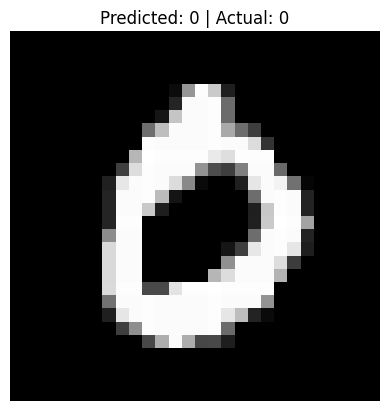

In [75]:
import matplotlib.pyplot as plt
import numpy as np
plt.imshow(x_test[3].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {np.argmax(pred[3])} | Actual: {y_test[3]}")
plt.axis("off")
plt.show()
